# Библиотеки

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## 8.17 Диаграмма рассеивания\точечная

In [2]:
np.random.seed(42)

a = np.random.randint(18, 65, 1000) #генерируем выборку возрастов 
s = a * 500 + np.random.normal(0, 10000, 1000) #генерируем выборку зарплат

In [3]:
d = pd.DataFrame({"Возраст": a, "Зарплата": s})
d.head()

,Возраст,Зарплата
0,56,38062.928092
1,46,17231.081305
2,32,24356.921121
3,60,18702.931453
4,25,17798.041779


<Axes: xlabel='Возраст', ylabel='Зарплата'>

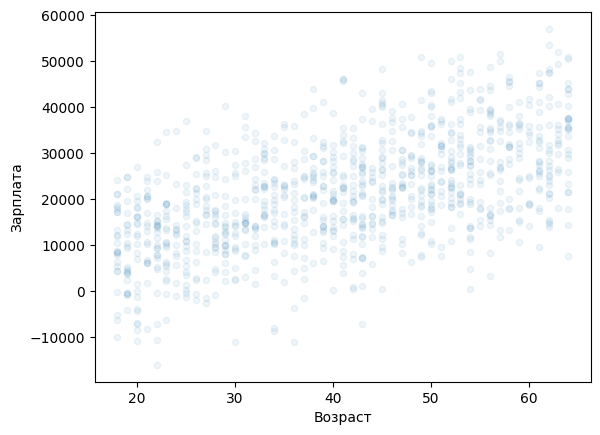

In [4]:
d.plot.scatter(x='Возраст', y='Зарплата', alpha=0.07)

<Axes: xlabel='Возраст', ylabel='Зарплата'>

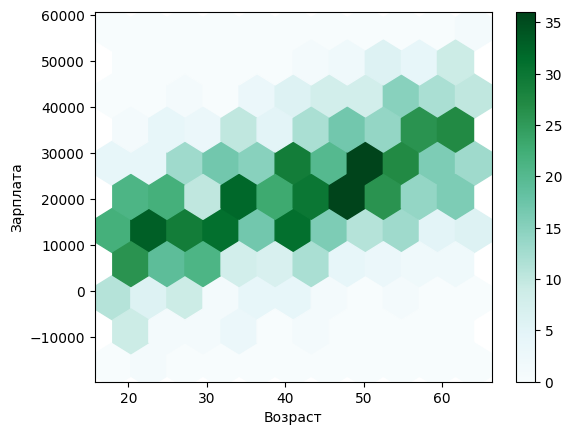

In [5]:
d.plot.hexbin(x='Возраст', y='Зарплата', gridsize=10)

<Axes: xlabel='Возраст', ylabel='Зарплата'>

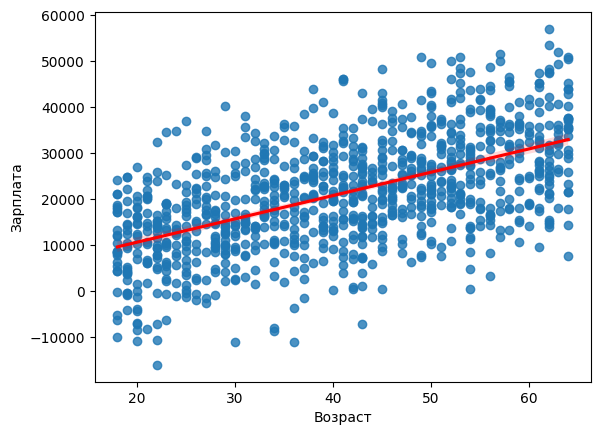

In [6]:
sns.regplot(data=d, x="Возраст", y="Зарплата", line_kws={"color": "red"})

## 8.18 Превращаем точки в "пузыри"

In [7]:
d["Стаж"] = (d["Возраст"] - 18).clip(lower=0)

<Axes: xlabel='Возраст', ylabel='Зарплата'>

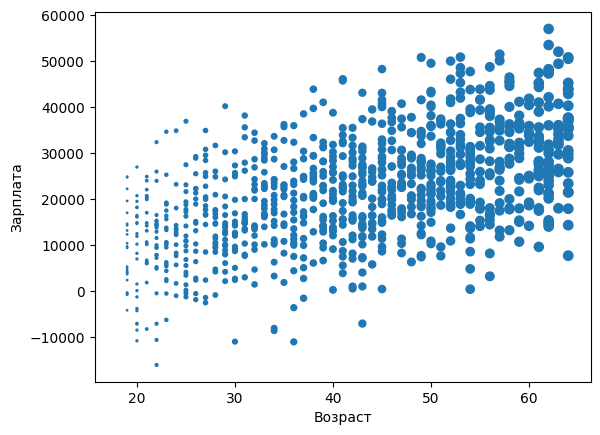

In [8]:
d.plot.scatter(x='Возраст', y='Зарплата', s='Стаж')

<Axes: xlabel='Возраст', ylabel='Зарплата'>

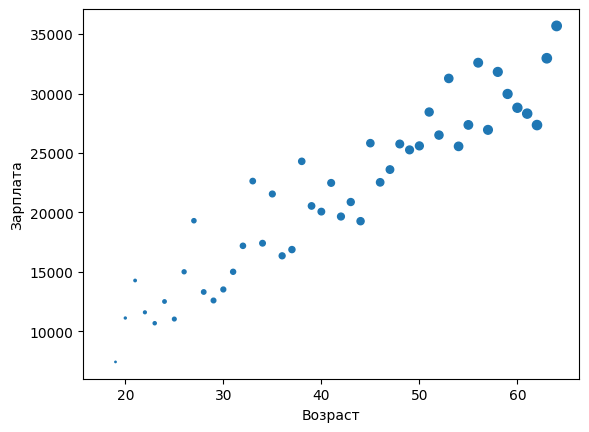

In [10]:
(d
.groupby(['Возраст'], as_index=False)
    .agg({'Стаж':'mean', 'Зарплата':'median'})
.plot.scatter(x='Возраст', y='Зарплата', s='Стаж')
)

## 8.19 Матрица скаттерплотов

array([[<Axes: xlabel='Возраст', ylabel='Возраст'>,
        <Axes: xlabel='Зарплата', ylabel='Возраст'>,
        <Axes: xlabel='Стаж', ylabel='Возраст'>],
       [<Axes: xlabel='Возраст', ylabel='Зарплата'>,
        <Axes: xlabel='Зарплата', ylabel='Зарплата'>,
        <Axes: xlabel='Стаж', ylabel='Зарплата'>],
       [<Axes: xlabel='Возраст', ylabel='Стаж'>,
        <Axes: xlabel='Зарплата', ylabel='Стаж'>,
        <Axes: xlabel='Стаж', ylabel='Стаж'>]], dtype=object)

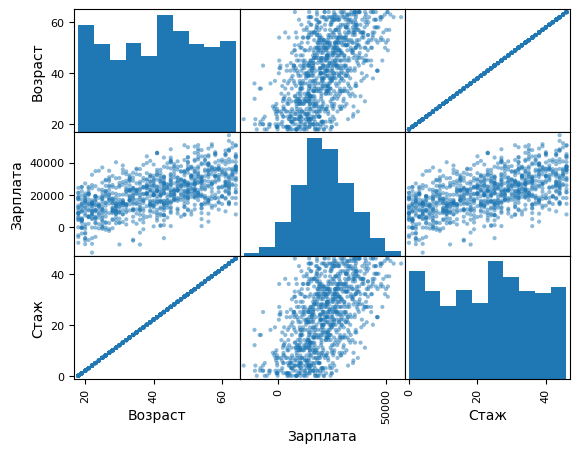

In [11]:
pd.plotting.scatter_matrix(frame=d, diagonal='hist')

array([[<Axes: xlabel='Возраст', ylabel='Возраст'>,
        <Axes: xlabel='Зарплата', ylabel='Возраст'>,
        <Axes: xlabel='Стаж', ylabel='Возраст'>],
       [<Axes: xlabel='Возраст', ylabel='Зарплата'>,
        <Axes: xlabel='Зарплата', ylabel='Зарплата'>,
        <Axes: xlabel='Стаж', ylabel='Зарплата'>],
       [<Axes: xlabel='Возраст', ylabel='Стаж'>,
        <Axes: xlabel='Зарплата', ylabel='Стаж'>,
        <Axes: xlabel='Стаж', ylabel='Стаж'>]], dtype=object)

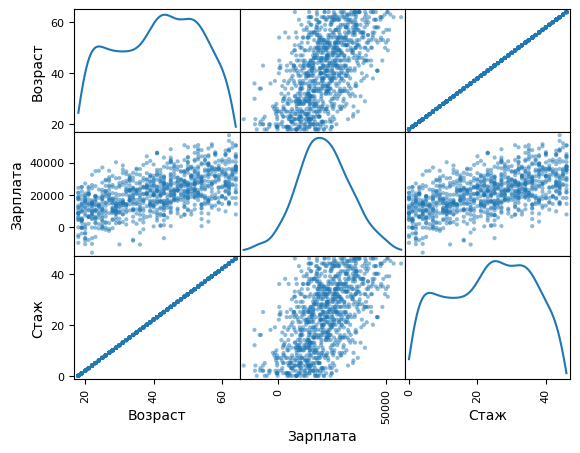

In [12]:
pd.plotting.scatter_matrix(frame=d, diagonal='kde')

# end